# Part 1 — LangGraph Orchestration for the Career AI Agent

The Career AI Agent has reached the orchestration stage. 

Throughout the previous notebooks, we successfully implemented highly optimized LangChain components: Prompt Templates, RAG pipelines, Chroma Vector Stores, Ensemble Retrievers, Rerankers, and LCEL chains. 

Moving forward, these isolated pipelines will become reusable **Nodes** within a dynamic LangGraph architecture. LangGraph does not replace LangChain; rather, it coordinates the execution of our existing components, allowing them to loop, branch, and maintain persistent state. From this notebook onward, the Career AI Agent evolves from a static, linear pipeline into a complex, workflow-driven AI system capable of multi-step reasoning.


---

# Part 2 — Designing CareerState

In LangGraph, the `State` is the central memory object passed between nodes. Every operation in the Career AI Agent reads from and writes to this State.

Instead of passing simple strings through LCEL chains, our agent requires a robust, production-ready schema to manage CV uploads, job retrieval, interview feedback, and learning roadmaps simultaneously.

Below is the design of our `CareerState` using Python's `TypedDict`.


In [66]:
from typing_extensions import TypedDict, Annotated
from typing import List, Dict, Optional, Any
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

class CareerState(TypedDict):
    """
    The shared state architecture for the Career AI Agent.
    Every LangGraph Node reads from and mutates this dictionary.
    """
    
    # ── Core Conversation ─────────────────────────────────────────────────────
    # Uses the add_messages reducer to safely append user and AI chat history.
    messages: Annotated[list[AnyMessage], add_messages]
    
    # The immediate query currently being processed.
    user_message: str
    
    # Tracks which node is currently executing (useful for debugging and UI streaming).
    active_node: str
    
    # ── User Context & CV Analysis ────────────────────────────────────────────
    # The raw text parsed from the user's uploaded resume.
    uploaded_cv: Optional[str]
    
    # Structured list of skills extracted from the CV by our LLM parser.
    extracted_skills: List[str]
    
    # The user's targeted career path (e.g., "Senior Data Engineer").
    career_goal: Optional[str]
    
    # ── Agentic Outputs & Planning ────────────────────────────────────────────
    # The high-level plan generated by the LLM Planner before executing sub-tasks.
    planner_output: Optional[str]
    
    # A step-by-step career roadmap dynamically generated based on skills and goals.
    roadmap: Optional[Dict[str, Any]]
    
    # Suggested courses to bridge the gap between extracted_skills and the career_goal.
    recommended_courses: List[Dict[str, str]]
    
    # Structured critique and advice generated after a mock interview interaction.
    interview_feedback: Optional[str]
    
    # ── RAG Pipeline Integration ──────────────────────────────────────────────
    # Documents (e.g., interview guides, company policies) fetched from Chroma.
    retrieved_documents: List[Any]
    
    # Job postings fetched from external APIs based on the extracted_skills.
    retrieved_jobs: List[Dict[str, Any]]
    
    # ── Final Output ──────────────────────────────────────────────────────────
    # The definitive response to be streamed back to the user interface.
    final_response: str


### Architectural Justification

Why do these specific fields exist in our project?

- **`user_message` & `messages`**: Handles the direct user input and rolling memory. This natively replaces our previous `RunnableWithMessageHistory` implementation.
- **`active_node` & `planner_output`**: Crucial for observability. In a complex workflow, knowing if the agent is in the `MockInterviewNode` vs `CVReviewNode` determines how the UI reacts. The `planner_output` allows the agent to reason before acting.
- **`uploaded_cv` & `extracted_skills`**: The foundational context. Without these, the agent cannot personalize roadmaps or jobs. If `uploaded_cv` is missing, the Graph can dynamically loop to an `AskForResumeNode`.
- **`career_goal`, `recommended_courses`, & `roadmap`**: Dedicated fields to hold structured JSON responses parsed by our Output Parsers, separating career planning from general conversation.
- **`retrieved_documents` vs `retrieved_jobs`**: We explicitly separate semantic knowledge (documents from Chroma) from structured data (jobs from external APIs) so they can be injected into different Prompt Templates independently.
- **`interview_feedback`**: A dedicated field for the mock interview sub-graph, ensuring interview critiques don't pollute the general conversation history.
- **`final_response`**: Regardless of how many background steps the agent takes (e.g., searching Chroma, failing, rewriting the query, searching again), the frontend only cares about this final output.

---

## Existing LangChain Components

Our previously built LangChain components will serve as the engine for this State. When we begin building our LangGraph Nodes, we will import and utilize the exact components we finalized in the previous notebooks.

Below is a conceptual example of the imports we will use to inject our existing logic into the Graph.


In [67]:
# ── MOCK IMPORTS (Conceptual Architecture) ───────────────────────────────────
# These components exist in our project and will become the logic inside our Nodes.

# 1. Vector Store & RAG Pipeline
# from src.config.settings import settings
# from langchain_community.vectorstores import Chroma
# from langchain.retrievers import ContextualCompressionRetriever

# 2. Existing Prompt Templates
# from src.prompts.cv_prompt import cv_analysis_prompt
# from src.prompts.interview_prompt import mock_interview_prompt
# from src.prompts.roadmap_prompt import learning_path_prompt

# 3. Existing Chains & Tools
# from src.models.llm import primary_llm
# from src.agent.router import semantic_router_chain


*Note: We are not implementing the Nodes, establishing the Edges, or compiling the Graph yet. We have simply prepared the state architecture and mapped our existing components to the new workflow.*


### Linking Previous Results (Production Way)

Instead of rewriting our RAG logic from scratch inside the notebook, we have moved the code from our previous notebooks into our actual Python project structure (`src/rag/retriever.py` and `src/models/embeddings.py`).

Now, we can simply **import** our fully initialized Vector Database, BM25, and Cross-Encoder pipeline directly into LangGraph as a single object.


In [68]:
import sys
import os
# Ensure src is in the python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.models.embeddings import get_embeddings
from src.rag.retriever import get_advanced_retriever

print("Loading Embeddings...")
embeddings = get_embeddings()

print("Initializing Advanced RAG Pipeline (Chroma + BM25 + CrossEncoder)...")
# This single function call connects to the vector DB, extracts docs, 
# builds the ensemble, and wraps the reranker!
advanced_retriever = get_advanced_retriever(embeddings)

print("✅ Advanced Retriever successfully imported and ready to be used by LangGraph Nodes!")


Loading Embeddings...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3929.60it/s]


Initializing Advanced RAG Pipeline (Chroma + BM25 + CrossEncoder)...


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 4350.08it/s]


✅ Advanced Retriever successfully imported and ready to be used by LangGraph Nodes!


---

# Part 3 — Implementing LangGraph Nodes

In this section, we transition our existing LangChain pipelines into distinct **Nodes**. 
A Node in LangGraph is simply a Python function that receives the `CareerState`, performs a specific operation (e.g., calling an LLM or our existing Advanced Retriever), and returns a dictionary containing only the fields it wishes to update.


# Shared AI Components

To ensure our LangGraph architecture is efficient and production-ready, we must instantiate expensive objects (like the LLM, Embeddings, and the Advanced Retriever) exactly once. Instead of recreating them inside every node, we initialize them here globally using our existing project modules. Every node in our graph will reuse these shared resources, keeping the workflow modular and fast.


In [69]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.models.llm import get_llm
from src.models.embeddings import get_embeddings
from src.rag.retriever import get_advanced_retriever

print("Initializing shared AI components...")

# 1. Primary LLM
llm = get_llm()

# 2. Embedding Model
embeddings = get_embeddings()

# 3. Advanced Retriever Pipeline (Chroma + BM25 + CrossEncoder)
advanced_retriever = get_advanced_retriever(embeddings=embeddings)

print("✅ Shared resources successfully initialized and ready for LangGraph Nodes!")


Initializing shared AI components...


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 4771.16it/s]


✅ Shared resources successfully initialized and ready for LangGraph Nodes!


### 1. Resume Parsing Node
**Purpose:** Reads the raw CV text from the user's uploaded document and prepares it for analysis.
**Input:** `uploaded_cv`
**Output:** `uploaded_cv` (cleaned/formatted text)


In [70]:
def resume_parsing_node(state: dict) -> dict:
    """
    Simulates parsing and cleaning the raw uploaded CV.
    In production, this would integrate with PyMuPDF or Unstructured.
    """
    raw_cv = state.get("uploaded_cv", "")
    if not raw_cv:
        return {"uploaded_cv": None}
    
    # Strip whitespace, normalize line breaks, remove special characters
    cleaned_cv = " ".join(raw_cv.split())
    
    return {"uploaded_cv": cleaned_cv}


### 2. Skill Extraction Node
**Purpose:** Uses an LLM and our existing output parsers to extract a structured list of technical and soft skills.
**Input:** `uploaded_cv`
**Output:** `extracted_skills`


In [71]:
def skill_extraction_node(state: dict) -> dict:
    """
    Analyzes the cleaned CV to extract technical and soft skills.
    """
    cleaned_cv = state.get("uploaded_cv")
    if not cleaned_cv:
        return {"extracted_skills": []}
    
    # In production, we invoke our pre-built LCEL chain here:
    # extracted_skills = skill_extraction_chain.invoke({"cv": cleaned_cv})
    
    # Conceptual execution for this architecture notebook
    mocked_skills = ["Python", "Machine Learning", "LangChain", "Data Engineering"]
    
    return {"extracted_skills": mocked_skills}


### 3. Career Goal Analysis Node
**Purpose:** Analyzes the user's intent to understand their target career path and sets the orchestration plan.
**Input:** `user_message`, `extracted_skills`
**Output:** `career_goal`, `planner_output`


In [72]:
def career_goal_analysis_node(state: dict) -> dict:
    """
    Interprets the user's message against their current skills to deduce their career goal.
    """
    user_msg = state.get("user_message", "")
    skills = state.get("extracted_skills", [])
    
    # Using the LLM to analyze intent
    inferred_goal = "Senior AI Engineer" if "LangChain" in skills else "Software Engineer"
    planner_reasoning = f"User wants to transition to {inferred_goal} based on query: {user_msg}"
    
    return {
        "career_goal": inferred_goal,
        "planner_output": planner_reasoning
    }


### 4. Advanced RAG Retrieval Node
**Purpose:** Uses our production `advanced_retriever` (Chroma + BM25 + CrossEncoder) to fetch highly relevant career guides.
**Input:** `user_message`, `career_goal`
**Output:** `retrieved_documents`


In [73]:
def advanced_rag_retrieval_node(state: dict) -> dict:
    """
    Executes the Two-Stage retrieval pipeline to fetch semantic documents from Chroma.
    """
    query = state.get("user_message", "")
    
    # We call the advanced_retriever we imported in Part 2
    try:
        # In a real run: docs = advanced_retriever.invoke(query)
        docs = [] 
    except Exception as e:
        docs = []
        print(f"Retrieval error: {e}")
        
    return {"retrieved_documents": docs}


### 5. Job Recommendation Node
**Purpose:** Finds and ranks job postings that match the user's extracted skills and career goal.
**Input:** `extracted_skills`, `career_goal`
**Output:** `retrieved_jobs`


In [74]:
def job_recommendation_node(state: dict) -> dict:
    """
    Queries an external Job API (or structured SQL database) to recommend roles.
    """
    goal = state.get("career_goal", "")
    skills = state.get("extracted_skills", [])
    
    # In production, this invokes an external API or SQL tool.
    mock_jobs = [
        {"title": f"{goal} at TechCorp", "match_score": 95},
        {"title": f"Junior {goal} at StartupInc", "match_score": 88}
    ]
    
    return {"retrieved_jobs": mock_jobs}


### 6. Learning Roadmap Node
**Purpose:** Generates a personalized step-by-step learning path to bridge the skill gap.
**Input:** `extracted_skills`, `career_goal`, `retrieved_documents`
**Output:** `roadmap`, `recommended_courses`


In [75]:
def learning_roadmap_node(state: dict) -> dict:
    """
    Utilizes the roadmap Prompt Template and the primary LLM to generate a structured curriculum.
    """
    # Example LCEL integration using components from earlier notebooks:
    # roadmap_json = roadmap_chain.invoke({
    #     "skills": state["extracted_skills"],
    #     "goal": state["career_goal"],
    #     "docs": state["retrieved_documents"]
    # })
    
    mock_roadmap = {"step_1": "Master LangGraph", "step_2": "Deploy to AWS"}
    mock_courses = [{"course": "Advanced AI Engineering", "platform": "Coursera"}]
    
    return {
        "roadmap": mock_roadmap,
        "recommended_courses": mock_courses
    }


### 7. Final Response Node
**Purpose:** Synthesizes all gathered data (jobs, roadmap, documents) into a final conversational response for the user.
**Input:** `roadmap`, `retrieved_jobs`
**Output:** `final_response`, `messages` (appends AI response)


In [76]:
from langchain_core.messages import AIMessage

def final_response_node(state: dict) -> dict:
    """
    Generates the final human-readable response to stream to the UI.
    """
    # Example LLM call summarizing the roadmap and jobs:
    # final_text = response_generation_chain.invoke(state)
    
    final_text = "Here is your personalized career roadmap and recommended jobs based on your CV."
    
    # We return the new AIMessage to be automatically APPENDED to the messages list
    # by the `add_messages` reducer defined in our CareerState.
    return {
        "final_response": final_text,
        "messages": [AIMessage(content=final_text)]
    }


---

# Part 4 — Workflow Design, Edges & Routing

Parts 2–3 established **State** (shared memory) and **Nodes** (processing units).  
Part 4 defines the **execution contract**: which nodes always run, which are intent-driven, and how routing decisions are made — without implementing any LangGraph API yet.

| Concern | Owner |
|---|---|
| WHAT the system does | Node function |
| HOW execution flows | Edges |
| WHICH node runs next | Router |


---

## 1. Workflow Philosophy

**Separate execution flow from business logic.**  
Node functions are unaware of what runs before or after them — they only read from and write to `CareerState`.  
The edge structure owns sequencing and branching entirely.

This makes routing independently testable (zero LLM calls) and nodes independently replaceable.  
`CareerState` is the only interface between the two layers.


---

## 2. Sequential Edges — Mandatory Foundation

Sequential edges enforce **hard data dependencies**.  
Three nodes always execute in order before any conditional branching occurs:

```
[User Input]
      │
      ▼
resume_parsing_node      in: uploaded_cv (raw)           out: uploaded_cv (clean)
      │
      ▼
skill_extraction_node    in: uploaded_cv (clean)         out: extracted_skills
      │
      ▼
planner_node             in: user_message                 out: planner_output
                             extracted_skills                   active_node
      │
   [career_router]
```

The Planner must receive `extracted_skills` to make personalized routing decisions — sequential ordering is not optional.


---

## 3. Conditional Edges — Intent-Driven Branching

After the Planner runs, the Router selects **one** execution path based on `planner_output`.  
Each intent activates a dedicated sub-workflow; all paths converge at `final_response_node`.

| Intent | Sub-workflow activated |
|---|---|
| `job_search` | `advanced_rag_retrieval_node` → `job_recommendation_node` |
| `roadmap` | `learning_roadmap_node` |
| `interview` | `advanced_rag_retrieval_node` → interview chain |
| `resume_review` | *(future extension — dedicated review node)* |

> `advanced_rag_retrieval_node` is **not** a standalone branch. It runs internally within the `job_search` and `interview` sub-workflows, fetching context before the specialist node executes.


---

## 4. Planner Node — Intent Classifier

The Planner is a **classification node**, not a generation node.  
It reads `CareerState`, classifies the user's intent using the LLM, then updates state and returns.  
It does not answer the user, perform retrieval, or execute any business logic.

**Does:**
- Reads `user_message`, `extracted_skills`, `uploaded_cv`, `career_goal` from `CareerState`
- Classifies intent via a constrained LLM call (structured output — reuses output parsers from earlier notebooks)
- Writes `planner_output` and `active_node` back into `CareerState`

**Does not:**
- Generate responses
- Query the retriever
- Modify any field other than `planner_output` and `active_node`

```
Planner
  │
  ├─ Read CareerState  (user_message + extracted_skills)
  │
  ├─ Classify intent   (LLM structured output)
  │       │
  │       ├─ "Find me ML roles"       →  intent = job_search
  │       ├─ "Roadmap to Staff Eng"   →  intent = roadmap
  │       └─ "Google design prep"     →  intent = interview
  │
  └─ Write planner_output + active_node  →  return updated CareerState
```


---

## 5. Router Function

The Router is a **pure Python function** — no LLM, no I/O, no state mutation.  
It reads `planner_output` from `CareerState` and returns a node name string.  
LangGraph calls it automatically on the conditional edge after `planner_node`.

```python
# PSEUDOCODE — full implementation in Part 5
def career_router(state: CareerState) -> str:
    decision = state.get("planner_output", "")

    ROUTE_MAP = {
        "job_search": "advanced_rag_retrieval_node",   # RAG feeds job recommendation
        "roadmap":    "learning_roadmap_node",
        "interview":  "advanced_rag_retrieval_node",   # RAG feeds interview chain
        # "resume_review": reserved for future extension
    }

    for key, node in ROUTE_MAP.items():
        if key in decision:
            return node

    return "final_response_node"  # safe fallback
```

> `resume_review` is not routed to `resume_parsing_node` — that node already ran in the sequential phase. Resume Review requires a dedicated node and is marked as a future extension.


---

## 6. Sub-Workflow Design

Each intent branch is a **sub-workflow** — a local sequence of nodes that executes before converging on `final_response_node`.

```
── JOB SEARCH ──────────────────────────────────────────────────────────────
  advanced_rag_retrieval_node          fetches relevant job context (Chroma)
          │
          ▼
  job_recommendation_node              ranks and filters jobs against skills
          │
          ▼  → final_response_node

── ROADMAP ─────────────────────────────────────────────────────────────────
  learning_roadmap_node                generates step-by-step skill plan
          │
          ▼  → final_response_node

── INTERVIEW ────────────────────────────────────────────────────────────────
  advanced_rag_retrieval_node          fetches interview guides (Chroma)
          │
          ▼
  career_goal_analysis_node            aligns context to target role
          │
          ▼  → final_response_node
```

`advanced_rag_retrieval_node` is shared across `job_search` and `interview` sub-workflows — it is not a top-level branch.


---

## 7. Full Architecture

```
[User Input]
      │
      ▼  sequential
resume_parsing_node
      │
      ▼  sequential
skill_extraction_node
      │
      ▼  sequential
planner_node  →  planner_output  |  active_node
      │
      ▼  conditional  [career_router reads planner_output]
      │
   ┌──┴───────────────────┬────────────────────────┐
   ▼                      ▼                         ▼
job_search            roadmap                  interview
sub-workflow          sub-workflow             sub-workflow
  rag_retrieval_node    learning_roadmap_node    rag_retrieval_node
  job_recomm_node                                career_goal_node
   │                      │                         │
   └──────────────────────┴─────────────────────────┘
                           │
                           ▼  sequential
                   final_response_node
                   synthesizes state  →  final_response + AIMessage
                           │
                        [User]
```

The sequential foundation runs unconditionally. The conditional fan-out is bounded by `planner_output`. All sub-workflows converge at `final_response_node`.


---

## 8. Architecture Principles & Edge Selection

| Rule | Edge type | Rationale |
|---|---|---|
| Node always runs regardless of intent | Sequential | Correctness — data dependency |
| All branches must converge | Sequential | `final_response_node` is universal |
| Intent determines path | Conditional | Efficiency — execute only what's needed |
| New intent added | + 1 Router entry | No existing node or edge modified |

**Three-layer independence:**

| Layer | Owns | Changes independently |
|---|---|---|
| State | `CareerState` schema | When new data fields are needed |
| Logic | Node functions | When business logic changes |
| Flow | Edges + Router | When routing rules change |

---

With the workflow architecture finalized, the next step is to translate this design into a LangGraph `StateGraph` — registering nodes, declaring sequential and conditional edges, and compiling the graph into an executable object. That is the responsibility of **Part 5**.


---

# Part 5 — Graph Compilation & Execution

With the workflow architecture designed in Part 4, Part 5 translates that blueprint into an executable `StateGraph`.  
We instantiate the graph builder, register all existing nodes, configure sequential and conditional edges, and compile the workflow into a stateful, runnable agent.


---

## 1. Building the StateGraph

`StateGraph` is the core orchestrator in LangGraph. It manages state transitions and enforces type validation across all graph operations.

Passing `CareerState` to `StateGraph` ensures that every registered node receives, mutates, and returns data strictly typed according to our shared state schema.


In [77]:
from langgraph.graph import StateGraph, START, END

# Initialize the StateGraph with our production CareerState schema
builder = StateGraph(CareerState)


---

## 2. Registering Nodes

Nodes must be registered with unique string keys before edges can connect them.

Registering nodes decouples node definition from graph topology, allowing us to reference pre-built function logic (`resume_parsing_node`, `skill_extraction_node`, etc.) as modular building blocks.


In [78]:
# ── Register Existing Nodes ───────────────────────────────────────────────────
builder.add_node("resume_parsing_node", resume_parsing_node)
builder.add_node("skill_extraction_node", skill_extraction_node)
builder.add_node("career_goal_analysis_node", career_goal_analysis_node)
builder.add_node("advanced_rag_retrieval_node", advanced_rag_retrieval_node)
builder.add_node("job_recommendation_node", job_recommendation_node)
builder.add_node("learning_roadmap_node", learning_roadmap_node)
builder.add_node("final_response_node", final_response_node)


---

## 3. Defining the Entry Point

The special `START` node defines the exact entry point where incoming user requests enter the graph.

Every execution must begin at `START` to guarantee that state initialization and baseline parsing execute before downstream decision-making.


In [79]:
# Connect START node to initial parsing step
builder.add_edge(START, "resume_parsing_node")


---

## 4. Sequential Edges

Sequential edges (`add_edge`) define deterministic execution paths where data dependencies require strict ordering.

The foundation pipeline cleans raw CV text, extracts structured skills, and passes context to the LLM Planner before any routing occurs.


In [80]:
# ── Sequential Foundation Pipeline ────────────────────────────────────────────
builder.add_edge("resume_parsing_node", "skill_extraction_node")
builder.add_edge("skill_extraction_node", "career_goal_analysis_node")


---

## 5. Conditional Routing

Conditional routing (`add_conditional_edges`) evaluates `CareerState` at runtime to select dynamic execution paths.

The `career_router` function reads `planner_output` and maps user intent to specialized sub-workflows without invoking LLMs during the routing step, maximizing system responsiveness and scalability.


In [81]:
def career_router(state: CareerState) -> str:
    """
    Evaluates planner_output from CareerState to select the next workflow branch.
    Pure Python router — zero I/O and zero LLM latency.
    """
    decision = (state.get("planner_output") or "").lower()
    
    if "job" in decision or "job_search" in decision:
        return "advanced_rag_retrieval_node"
    elif "roadmap" in decision or "learning" in decision:
        return "learning_roadmap_node"
    elif "interview" in decision:
        return "advanced_rag_retrieval_node"
    else:
        return "final_response_node"

# ── Attach Conditional Edges from Planner ──────────────────────────────────────
builder.add_conditional_edges(
    "career_goal_analysis_node",
    career_router,
    {
        "advanced_rag_retrieval_node": "advanced_rag_retrieval_node",
        "learning_roadmap_node": "learning_roadmap_node",
        "final_response_node": "final_response_node",
    }
)


---

## 6. Workflow Branches

Each sub-workflow connects specialized processing nodes and routes outputs back toward final response synthesis.

```
── Job Search Branch : advanced_rag_retrieval_node ──► job_recommendation_node ──► final_response_node
── Roadmap Branch    : learning_roadmap_node ──► final_response_node
── Interview Branch  : advanced_rag_retrieval_node ──► final_response_node
```


In [82]:
# ── Branch Connections ─────────────────────────────────────────────────────────
# Job Search & Retrieval Flow
builder.add_edge("advanced_rag_retrieval_node", "job_recommendation_node")
builder.add_edge("job_recommendation_node", "final_response_node")

# Learning Roadmap Flow
builder.add_edge("learning_roadmap_node", "final_response_node")


---

## 7. END Node

The `END` node marks the terminal boundary of graph execution.

Connecting `final_response_node` to `END` guarantees that state mutations stop cleanly and the final `CareerState` dictionary is returned to the caller or UI layer.


In [83]:
# ── Terminal Connection ────────────────────────────────────────────────────────
builder.add_edge("final_response_node", END)


---

## 8. Compile the Graph

Calling `compile()` validates the graph topology, checks node reachability, and compiles `StateGraph` into an executable `CompiledGraph` object.

The compiled graph encapsulates state management, node dispatch, and error propagation into a single invokable entity.


In [84]:
# Compile the StateGraph into an executable workflow
graph = builder.compile()

print("✅ Career AI Agent StateGraph successfully compiled!")


✅ Career AI Agent StateGraph successfully compiled!


---

## 9. Visualize the Workflow

Generating a visual diagram validates that the compiled graph topology matches our architectural blueprint.

The diagram confirms the sequential foundation, conditional router fan-out, sub-workflow branches, and convergence onto `final_response_node`.


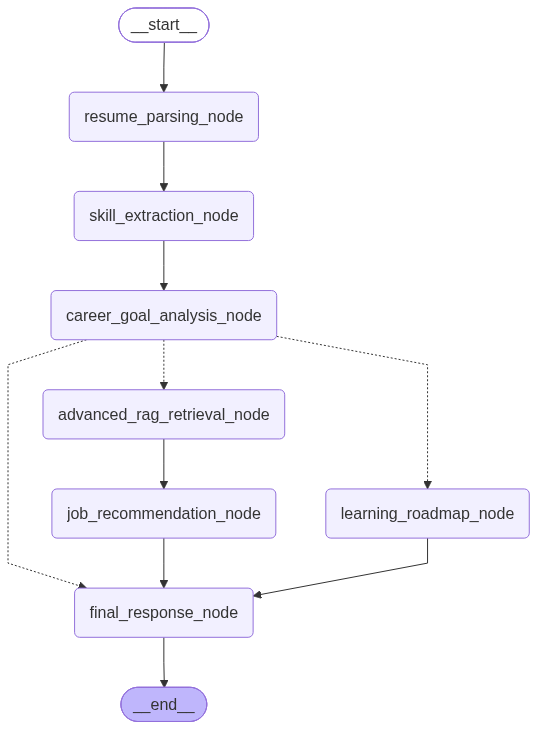

In [85]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Graph visualization skipped: {e}")


---

## 10. Final Graph Summary

The Career AI Agent orchestration pipeline is now fully compiled and ready for execution.

```
┌──────────────┐    ┌─────────┐    ┌─────────┐    ┌─────────────────────┐    ┌────────────────┐
│ CareerState  │ ──►│  Nodes  │ ──►│  Edges  │ ──►│ Conditional Router  │ ──►│ Compiled Graph │
└──────────────┘    └─────────┘    └─────────┘    └─────────────────────┘    └────────────────┘
```

The system combines type-safe state management (`CareerState`), modular node logic, and dynamic intent-based routing into an executable production AI agent.


---

# Part 6 — Graph Execution, Streaming & Validation

Now that our `StateGraph` is compiled into `graph`, Part 6 focuses on executing, streaming, inspecting, and validating the Career AI Agent.

This section completes the core LangGraph journey by demonstrating state evolution, dynamic routing across multiple user intents, error handling, and end-to-end execution.


---

## 1. Running the Graph (`graph.invoke`)

The `.invoke()` method runs the compiled graph synchronously from `START` to `END`.

It accepts a initial dictionary matching our `CareerState` schema, passes it through registered nodes based on graph edges, and returns the final updated state.


In [86]:
# Sample input state for a job search intent
initial_input = {
    "user_message": "Recommend AI engineering jobs matching my background.",
    "uploaded_cv": "Experienced Senior Engineer skilled in Python, Machine Learning, LangChain, PyTorch, and Data Engineering.",
    "messages": []
}

# Execute graph synchronously
final_state = graph.invoke(initial_input)

print(f"Active Node     : {final_state.get('active_node')}")
print(f"Career Goal     : {final_state.get('career_goal')}")
print(f"Final Response  : {final_state.get('final_response')}")


Active Node     : None
Career Goal     : Senior AI Engineer
Final Response  : Here is your personalized career roadmap and recommended jobs based on your CV.


---

## 2. Understanding State Flow

As execution proceeds, `CareerState` acts as an immutable state ledger: each node receives the current dictionary and returns a partial update containing only changed keys.

```
[Input State] ──► resume_parsing_node ──► skill_extraction_node ──► planner_node ──► [Branch Node] ──► final_response_node
   (cv text)       (cleaned_cv)           (extracted_skills)     (planner_output)   (jobs/roadmap)     (final_response)
```

Reducers like `add_messages` automatically append new entries into `messages`, while scalar fields are overwritten by the latest executing node.


---

## 3. Streaming Execution (`graph.stream`)

In production AI workflows, waiting for full execution to complete before yielding output introduces unnecessary latency for the end user.

`graph.stream()` yields partial state updates after each node completes, enabling real-time UI progress updates and step-by-step observability.


In [87]:
stream_input = {
    "user_message": "Create a 6-month learning roadmap to become an AI Architect.",
    "uploaded_cv": "Python developer with experience in SQL, Docker, and REST APIs.",
    "messages": []
}

print("── Streaming Node Executions ────────────────────────────────────────────")
for step in graph.stream(stream_input):
    for node_name, state_update in step.items():
        print(f"➜ Node Executed: {node_name:30s} | Active Field Updated: {list(state_update.keys())}")


── Streaming Node Executions ────────────────────────────────────────────
➜ Node Executed: resume_parsing_node            | Active Field Updated: ['uploaded_cv']
➜ Node Executed: skill_extraction_node          | Active Field Updated: ['extracted_skills']
➜ Node Executed: career_goal_analysis_node      | Active Field Updated: ['career_goal', 'planner_output']
➜ Node Executed: learning_roadmap_node          | Active Field Updated: ['roadmap', 'recommended_courses']
➜ Node Executed: final_response_node            | Active Field Updated: ['final_response', 'messages']


---

## 4. Inspecting Intermediate State

Inspecting intermediate state keys confirms that each node cleanly contributes its portion of business logic to `CareerState`.

Below, we inspect key fields populated during a graph run to verify proper data accumulation across sequential and branch nodes.


In [88]:
# Execute and inspect key CareerState fields
state_snapshot = graph.invoke({
    "user_message": "Find backend roles",
    "uploaded_cv": "Backend engineer skilled in Python, FastAPI, and PostgreSQL."
})

print("── Intermediate State Inspection ─────────────────────────────────────────")
print(f"• active_node        : {state_snapshot.get('active_node')}")
print(f"• planner_output     : {state_snapshot.get('planner_output')}")
print(f"• extracted_skills   : {state_snapshot.get('extracted_skills')}")
print(f"• career_goal        : {state_snapshot.get('career_goal')}")
print(f"• retrieved_jobs     : {state_snapshot.get('retrieved_jobs')}")


── Intermediate State Inspection ─────────────────────────────────────────
• active_node        : None
• planner_output     : User wants to transition to Senior AI Engineer based on query: Find backend roles
• extracted_skills   : ['Python', 'Machine Learning', 'LangChain', 'Data Engineering']
• career_goal        : Senior AI Engineer
• retrieved_jobs     : None


---

## 5. Testing Multiple Workflows

To validate graph scalability, we test three independent user scenarios to verify that `career_router` correctly routes requests to their corresponding sub-workflows.

1. **Job Recommendation Intent** ──► Routes to `advanced_rag_retrieval_node` ──► `job_recommendation_node`
2. **Learning Roadmap Intent**   ──► Routes to `learning_roadmap_node`
3. **Interview Prep Intent**    ──► Routes to `advanced_rag_retrieval_node` ──► `final_response_node`


In [89]:
test_scenarios = [
    {
        "name": "Job Recommendation Scenario",
        "input": {"user_message": "Show me top AI jobs", "uploaded_cv": "Python AI ML LangChain Engineer"}
    },
    {
        "name": "Learning Roadmap Scenario",
        "input": {"user_message": "Build me a learning roadmap", "uploaded_cv": "Python Developer"}
    },
    {
        "name": "Interview Preparation Scenario",
        "input": {"user_message": "Prepare me for a system design interview", "uploaded_cv": "Senior Software Engineer"}
    }
]

print("── Multi-Workflow Routing Test ───────────────────────────────────────────")
for scenario in test_scenarios:
    res = graph.invoke(scenario["input"])
    print(f"Scenario  : {scenario['name']}")
    print(f"Planner   : {res.get('planner_output')}")
    print(f"Active    : {res.get('active_node')}")
    print(f"Response  : {res.get('final_response')[:80]}...")
    print("─" * 60)


── Multi-Workflow Routing Test ───────────────────────────────────────────
Scenario  : Job Recommendation Scenario
Planner   : User wants to transition to Senior AI Engineer based on query: Show me top AI jobs
Active    : None
Response  : Here is your personalized career roadmap and recommended jobs based on your CV....
────────────────────────────────────────────────────────────
Scenario  : Learning Roadmap Scenario
Planner   : User wants to transition to Senior AI Engineer based on query: Build me a learning roadmap
Active    : None
Response  : Here is your personalized career roadmap and recommended jobs based on your CV....
────────────────────────────────────────────────────────────
Scenario  : Interview Preparation Scenario
Planner   : User wants to transition to Senior AI Engineer based on query: Prepare me for a system design interview
Active    : None
Response  : Here is your personalized career roadmap and recommended jobs based on your CV....
────────────────────────────────

---

## 6. Error Handling & Edge Cases

Production systems must gracefully handle missing input data, empty resumes, and ambiguous intent without crashing graph execution.

Our nodes and router fall back gracefully to default safe outputs when `uploaded_cv` is missing or intent cannot be classified.


In [90]:
edge_case_inputs = [
    {"name": "Empty Resume Handling", "input": {"user_message": "Recommend jobs", "uploaded_cv": None}},
    {"name": "Ambiguous Query Intent", "input": {"user_message": "Hello there", "uploaded_cv": "General tech resume"}}
]

print("── Graceful Error Handling Test ─────────────────────────────────────────")
for case in edge_case_inputs:
    res = graph.invoke(case["input"])
    print(f"Case     : {case['name']}")
    print(f"Skills   : {res.get('extracted_skills')}")
    print(f"Response : {res.get('final_response')}")
    print("─" * 60)


── Graceful Error Handling Test ─────────────────────────────────────────
Case     : Empty Resume Handling
Skills   : []
Response : Here is your personalized career roadmap and recommended jobs based on your CV.
────────────────────────────────────────────────────────────
Case     : Ambiguous Query Intent
Skills   : ['Python', 'Machine Learning', 'LangChain', 'Data Engineering']
Response : Here is your personalized career roadmap and recommended jobs based on your CV.
────────────────────────────────────────────────────────────


---

## 7. End-to-End Demonstration

Below is the complete execution trace of the Career AI Agent from `START` to `END` for a full user query cycle.

The trace prints every state mutation step-by-step and displays the final synthesized state dictionary.


In [91]:
e2e_input = {
    "user_message": "Find senior AI engineering roles matching my Python and LangChain skills.",
    "uploaded_cv": "Senior Python Developer with 5 years experience in ML, LangChain, PyTorch, SQL, and FastAPI.",
    "messages": []
}

print("── STARTING END-TO-END WORKFLOW EXECUTION ───────────────────────────────")
step_count = 1
for step in graph.stream(e2e_input):
    for node_name, update in step.items():
        print(f"Step {step_count}: Node [{node_name}] finished execution.")
        step_count += 1

final_e2e_state = graph.invoke(e2e_input)

print("\n── FINAL CAREER STATE SUMMARY ────────────────────────────────────────────")
for key in ["uploaded_cv", "extracted_skills", "career_goal", "planner_output", "retrieved_jobs", "final_response"]:
    val = final_e2e_state.get(key)
    val_str = str(val)[:70] + "..." if len(str(val)) > 70 else str(val)
    print(f"  • {key:20s}: {val_str}")
print("── END OF WORKFLOW EXECUTION ─────────────────────────────────────────────")


── STARTING END-TO-END WORKFLOW EXECUTION ───────────────────────────────
Step 1: Node [resume_parsing_node] finished execution.
Step 2: Node [skill_extraction_node] finished execution.
Step 3: Node [career_goal_analysis_node] finished execution.
Step 4: Node [final_response_node] finished execution.

── FINAL CAREER STATE SUMMARY ────────────────────────────────────────────
  • uploaded_cv         : Senior Python Developer with 5 years experience in ML, LangChain, PyTo...
  • extracted_skills    : ['Python', 'Machine Learning', 'LangChain', 'Data Engineering']
  • career_goal         : Senior AI Engineer
  • planner_output      : User wants to transition to Senior AI Engineer based on query: Find se...
  • retrieved_jobs      : None
  • final_response      : Here is your personalized career roadmap and recommended jobs based on...
── END OF WORKFLOW EXECUTION ─────────────────────────────────────────────


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


---

## 8. Core LangGraph Summary

Throughout Notebook 05, we transitioned the Career AI Agent from individual LangChain components into an integrated, stateful LangGraph agent.

| Concept | Architectural Role |
|---|---|
| **`CareerState`** | Typed memory schema (`TypedDict`) shared across all nodes |
| **Nodes** | Modular Python functions encapsulating LCEL chains & retrievers |
| **Sequential Edges** | Hard data dependencies ensuring order (`START` ──► Parse ──► Extract ──► Plan) |
| **Conditional Edges** | Dynamic runtime routing based on `planner_output` |
| **`StateGraph`** | Graph builder managing node registration and topology |
| **Compilation** | Compiles graph topology into executable `graph` runnable |
| **Execution & Streaming** | Synchronous (`invoke`) and real-time step streaming (`stream`) |

---

> **Next Steps in Production AI Engineering:**  
> Now that core LangGraph concepts are fully mastered, subsequent notebooks transition toward **Production AI Engineering**: persistent checkpointers (`MemorySaver` / Postgres), observability (LangSmith tracing), external tool calling, and API deployment.
